In [1]:
!pip install scikit-learn
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

X = data.data      # variáveis (entrada)
y = data.target    # preço (saída)

df = pd.DataFrame(data.data, columns=data.feature_names)
df['preco'] = data.target

df.corr()['preco'].sort_values(ascending=False)


preco         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: preco, dtype: float64

Podemos gerar um gráfico padrão linear com o maior dado correlato ao preço para verificar a dispersão dos pontos.

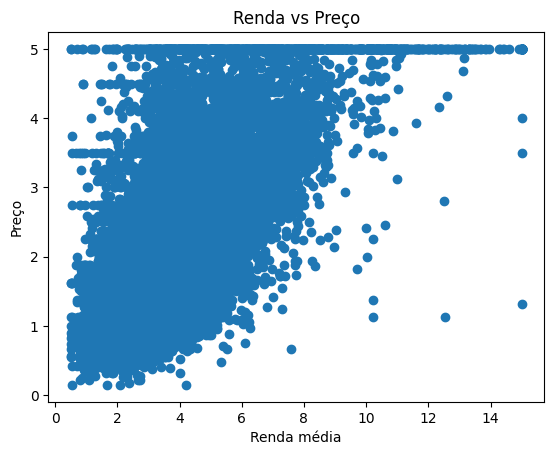

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df['MedInc'], df['preco'])
plt.xlabel("Renda média")
plt.ylabel("Preço")
plt.title("Renda vs Preço")
plt.show()

Insights deste gráfico:

- 1° Porque utilizar o MedInc? Pois ele é quem tem maior correlação prévia no preço da casa ao consultar as correlações da coluna preço no Df;

- 2° É possível confirmar o primeiro ponto analisando o gráfico, que claramente tem um correlção positiva, quanto maior a renda média, maior o preço da casa;

- 3° Provavélmente o gráfico linear não é o melhor bom, pois não é necessáriamente uma reta, mas sim um parabola, contudo podemos testar e utilizar de baseline para nosso desenvolvimento;

In [3]:
from sklearn.model_selection import train_test_split

def get_train(df):
    X = df.drop('preco', axis=1)
    y = df['preco']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=240
    )
    return X_train, X_test, y_train, y_test

Criando um dummy model para ter uma base line do meu modelo

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = get_train(df)

def get_dummy(X_train, y_train, X_test, y_test):
    # baseline
    dummy = DummyRegressor(strategy="mean")

    dummy.fit(X_train, y_train)

    y_dummy_pred = dummy.predict(X_test)

    r2 = r2_score(y_test, y_dummy_pred)
    mae = mean_absolute_error(y_test, y_dummy_pred)

    print("Baseline (Dummy)")
    print("R²:", r2_score(y_test, y_dummy_pred))
    print("MAE:", mean_absolute_error(y_test, y_dummy_pred))
    return {'r2':r2, 'mae':mae, 'pred':y_dummy_pred}

dummy_results = get_dummy(X_train, y_train, X_test, y_test)

Baseline (Dummy)
R²: -0.000538168227137259
MAE: 0.9116421194693398


Treino o modelo com dados de treino

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

def get_linear_model(X_train, y_train, X_test, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print("Linear Regression Model")
    print("R²:", r2)
    print("MAE:", mae)
    
    return {'r2':r2, 'mae':mae, 'pred':y_pred}

linear_results_1 = get_linear_model(X_train, y_train, X_test, y_test)

Linear Regression Model
R²: 0.594842408323841
MAE: 0.53177751072118


O modelo linear apresenta um R² de aproximadamente 0.59, indicando que consegue explicar uma parte relevante da variação dos preços, embora ainda existam fatores importantes não capturados pelo modelo.

O MAE de aproximadamente 0.53 indica que, em média, o modelo erra cerca de 0.53 unidades no preço. Considerando que o preço varia até cerca de 5, isso representa um erro médio aproximado de 10%, o que é razoável, mas ainda indica espaço para melhoria.

In [6]:
from sklearn.ensemble import RandomForestRegressor

def get_random_forest_model(X_train, y_train, X_test, y_test):
    model = RandomForestRegressor(random_state=240)

    model.fit(X_train, y_train)

    y_pred_rf = model.predict(X_test)

    r2 = r2_score(y_test, y_pred_rf)
    mae = mean_absolute_error(y_test, y_pred_rf)

    print("Random Forest Regressor Model")

    print("R²:", r2)
    print("MAE:", mae)

    return {'r2':r2, 'mae':mae, 'pred':y_pred_rf}

random_forest_results_1 = get_random_forest_model(X_train, y_train, X_test, y_test)

Random Forest Regressor Model
R²: 0.8084184078688911
MAE: 0.33334859010012935


In [8]:
print('Random Forest Results:\n', 'r2:',random_forest_results_1['r2'],'mae:', random_forest_results_1['mae'],'\n')
print('Linear Linear Results:\n', 'r2:',linear_results_1['r2'],'mae:', linear_results_1['mae'],'\n')
print('Dummy Results:\n', 'r2:',dummy_results['r2'],'mae:', dummy_results['mae'])

Random Forest Results:
 r2: 0.8084184078688911 mae: 0.33334859010012935 

Linear Linear Results:
 r2: 0.594842408323841 mae: 0.53177751072118 

Dummy Results:
 r2: -0.000538168227137259 mae: 0.9116421194693398


O modelo random florest apresenta um R² de aproximadamente 0.80, indicando que consegue explicar boa parte da variação dos preços.

O MAE de aproximadamente 0.33 indica que, em média, o modelo erra cerca de 0.33 unidades no preço. Considerando que o preço varia até cerca de 5, isso representa um erro médio aproximado de 6%, o que é bom.

Contudo devemos olhar a árvore de decisão deste modelo para verificar as decisões sendo tomadas.

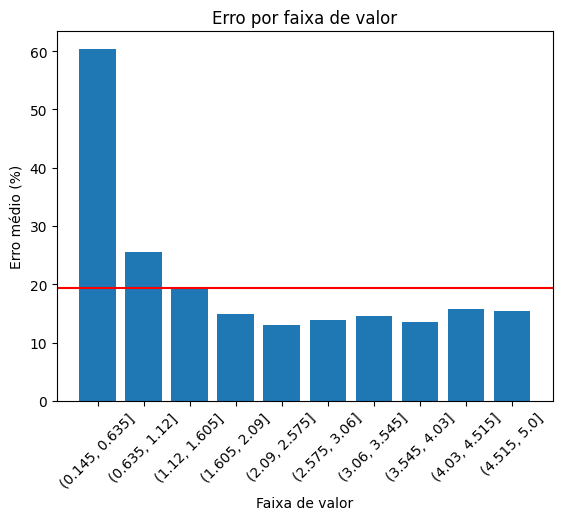

In [81]:
import pandas as pd
import numpy as np


df_rf_side = pd.DataFrame({
    'real': y_test,
    'pred':  random_forest_results_1['pred']
})

df_rf_side['erro_relativo'] = (np.abs(df_rf_side['real'] - df_rf_side['pred']) / df_rf_side['real'])*100
df_rf_side['faixa'] = pd.cut(df_rf_side['real'], bins=10)

resumo = df_rf_side.groupby('faixa')['erro_relativo'].mean().reset_index()

plt.bar(resumo['faixa'].astype(str), resumo['erro_relativo'], linestyle='--')
plt.xticks(rotation=45)
plt.axhline(y=df_rf_side['erro_relativo'].mean(), color='red')
plt.ylabel("Erro médio (%)")
plt.xlabel("Faixa de valor")
plt.title("Erro por faixa de valor")
plt.show()

Este gráfico representa uma forte necessidade de apuração na estimativa das casas cujo o valor esta entre 0.145 e 0.635

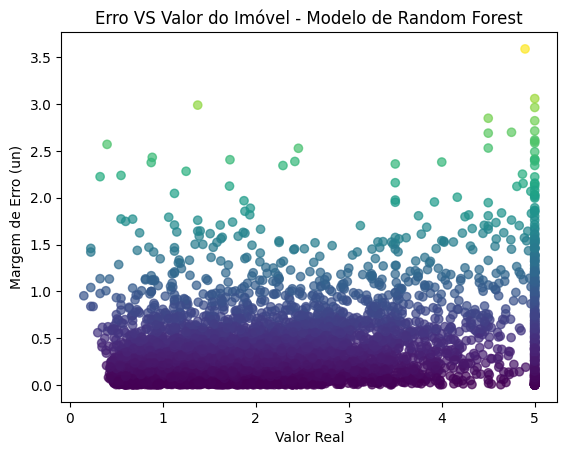

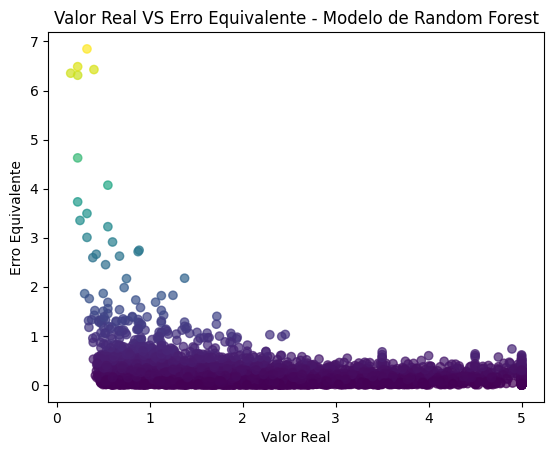

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def generate_insights_graph(y_test, predict, title):
    erro = np.abs(y_test - predict)

    plt.scatter(y_test, erro, c=erro, cmap='viridis', alpha=0.7)
    

    plt.xlabel("Valor Real")
    plt.ylabel("Margem de Erro (un)")
    plt.title(f'Erro VS Valor do Imóvel - {title}')
    plt.show()

    erro_percent = np.abs(y_test - predict) / y_test

    plt.scatter(y_test, erro_percent, c=erro_percent, cmap='viridis', alpha=0.7)
    plt.xlabel("Valor Real")
    plt.ylabel("Erro Equivalente")
    plt.title(f'Valor Real VS Erro Equivalente - {title}')
    plt.show()

generate_insights_graph(y_test, random_forest_results_1['pred'], 'Modelo de Random Forest')

In [30]:
faixas_total = pd.cut(pd.concat([y_train, y_test]), bins=10)
contagem_total = faixas_total.value_counts().sort_index()

media = contagem_total.mean()

print('média de dados por faixa:', media)
print('dados por faixa:')
print(contagem_total)

# --- distribuição teste ---
faixas_test = pd.cut(y_test, bins=10)
contagem_test = faixas_test.value_counts().sort_index()

print('\n dados por faixa: teste')
print(contagem_test)

# --- distribuição treino ---
faixas_train = pd.cut(y_train, bins=10)
contagem_train = faixas_train.value_counts().sort_index()

print('\n dados por faixa: treino')
print(contagem_train)

média de dados por faixa: 2064.0
dados por faixa:
preco
(0.145, 0.635]     877
(0.635, 1.12]     3612
(1.12, 1.605]     4099
(1.605, 2.09]     3771
(2.09, 2.575]     2799
(2.575, 3.06]     1769
(3.06, 3.545]     1239
(3.545, 4.03]      752
(4.03, 4.515]      479
(4.515, 5.0]      1243
Name: count, dtype: int64

 dados por faixa: teste
preco
(0.145, 0.635]     273
(0.635, 1.12]     1096
(1.12, 1.605]     1266
(1.605, 2.09]     1103
(2.09, 2.575]      852
(2.575, 3.06]      516
(3.06, 3.545]      366
(3.545, 4.03]      215
(4.03, 4.515]      150
(4.515, 5.0]       355
Name: count, dtype: int64

 dados por faixa: treino
preco
(0.145, 0.635]     604
(0.635, 1.12]     2516
(1.12, 1.605]     2833
(1.605, 2.09]     2668
(2.09, 2.575]     1947
(2.575, 3.06]     1253
(3.06, 3.545]      873
(3.545, 4.03]      537
(4.03, 4.515]      329
(4.515, 5.0]       888
Name: count, dtype: int64


Os gráficos mostram que o modelo apresenta um comportamento relativamente estável nas faixas intermediárias de valores, com erro distribuído de forma consistente. No entanto, observa-se um aumento significativo do erro nas faixas mais baixas, especialmente entre 0.145 e 0.635.

Esse comportamento é explicado principalmente pela menor representatividade desses dados no conjunto, que possui apenas 877 observações nessa faixa, enquanto a média por faixa é de aproximadamente 2064, o que limita a capacidade do modelo de generalizar bem nesses casos.

Além disso, ao analisar o erro percentual, nota-se que os maiores desvios relativos ocorrem nessa faixa inferior, em parte devido à própria natureza da métrica, que amplifica erros em valores pequenos.

Outro ponto relevante é a concentração de observações no valor máximo (5), causada por um CAP no dataset, onde valores acima desse limite foram truncados. Isso introduz ruído no treinamento, já que diferentes imóveis com valores reais distintos passam a ter o mesmo target, dificultando a aprendizagem do modelo nessa região.

Como possíveis melhorias, podem ser exploradas técnicas como transformação logarítmica da variável alvo, uso de pesos amostrais para balancear regiões menos representadas e engenharia de features, especialmente relacionadas à localização. Nesse sentido, a aplicação de clustering geográfico pode ajudar o modelo a capturar melhor padrões regionais que não são bem representados apenas por latitude e longitude isoladamente.